# Budget Constrained Optimization

> [Heterogeneous Causal Learning for Effectiveness Optimization in User Marketing](https://arxiv.org/abs/2004.09702) 논문에 제안된 방법을 Python 코드로 재현했습니다.

- 기존 uplift 모델은 이질적 처치 효과를 추정할 수 있지만, 비용 대비 이익을 충분히 반영하지 못합니다.

- 마케팅처럼 예산이 제한된 환경에서는, 비용을 고려하면서 효과를 최대화하는 처치 효과 최적화(treatment effect optimization) 접근이 필요합니다.

- 이를 위해 다음 알고리즘들을 활용합니다.
  - Duality R-learner
  - Direct Ranking Model (DRM)
  - Constrained Ranking Models

## Setup

In [1]:
%pip -q install fractional-uplift

Note: you may need to restart the kernel to use updated packages.


In [51]:
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.dummy import DummyClassifier

import fractional_uplift as fr
from econml.dml import CausalForestDML

import matplotlib.pyplot as plt

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

import warnings
warnings.filterwarnings("ignore")

### CriteoWithSyntheticCostAndSpend Dataset

CriteoWithSyntheticCostAndSpend 데이터셋은  
수익(spend)과 비용(cost)을 동시에 포함하고 있어, 비용을 고려한 처치 최적화 실험에 적합합니다. 

- 주요 컬럼:
  - `treatment`: 광고/프로모션 노출 여부 (0/1)
  - `spend`: 사용자가 발생시킨 매출
  - `cost`: 해당 고객에게 treatment를 줄 때 들어간 비용
  - `treatment_propensity`: treatment 할당 확률 (상수 0.85)
  - `sample_weight`: 비균등 서브샘플링 보정을 위한 모집단 가중치
  - `criteo.features`: feature 컬럼 이름 리스트

In [52]:
criteo = fr.example_data.CriteoWithSyntheticCostAndSpend.load()

features = criteo.features
train_df = criteo.train_data.copy() 
test_df  = criteo.test_data.copy()

print(train_df.shape)
print(test_df.shape)
display(train_df.head())

(72053, 19)
(20333, 19)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,treatment_propensity,cost_percentage,spend,cost,sample_weight
44,12.616365,10.059654,8.964588,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0.85,0.000000,0.000000,0.000000,100.0
187,12.616365,10.059654,8.904597,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0.85,0.000000,0.000000,0.000000,100.0
484,22.377238,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0.85,0.000000,0.000000,0.000000,100.0
528,12.616365,10.059654,8.350682,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,16.226044,5.300375,-0.168679,1,0,0.85,0.000000,0.000000,0.000000,100.0
1108,14.617627,10.059654,8.489929,3.907662,13.253813,4.115453,-2.411115,4.833815,3.809530,42.176324,5.737292,-0.560340,1,1,0.85,0.090777,36.459294,3.309655,1.0


In [53]:
# Train
X_train = train_df[features].values.astype(np.float32)
T_train = train_df["treatment"].values.astype(int)
Yg_train = train_df["spend"].values.astype(float)
Yc_train = train_df["cost"].values.astype(float)
W_train = train_df["sample_weight"].values.astype(float)
e_train = train_df["treatment_propensity"].values.astype(float)

# Test
X_test  = test_df[features].values.astype(np.float32)      
T_test  = test_df["treatment"].values.astype(int)          
Yg_test = test_df["spend"].values.astype(float)            
Yc_test = test_df["cost"].values.astype(float)             
W_test  = test_df["sample_weight"].values.astype(float)    
e_test  = test_df["treatment_propensity"].values.astype(float)  

## Duality R-learner

Duality R-learner는 다음 두 단계를 결합한 방식입니다.

1. 사용자별 처치 효과(CATE) 추정
   - $\tau_r(x)$: gain uplift (매출 증가 효과)
   - $\tau_c(x)$: cost uplift (비용 증가 효과)
   > 본 노트북에서는 이론적으로는 Duality R-learner 프레임워크를 따르지만,
   > CATE 추정 단계에서는 R-learner를 직접 구현하지 않고,
   > `econml` 라이브러리의 `CausalForestDML`을 사용합니다.

2. 예산 제약을 고려한 듀얼 최적화
   - 라그랑지 승수 $\lambda$를 학습하여 최적 정책을 도출합니다.

우리가 풀고 싶은 문제는 다음과 같습니다.

- 예산 $B$ 하에서

  $$
  \max_{z_i \in \{0,1\}} \sum_i \tau_r(x^{(i)}) z_i
  \quad \text{s.t.} \quad
  \sum_i \tau_c(x^{(i)}) z_i \le B
  $$

- $z_i = 1$ 이면 고객 $i$ 에게 프로모션/광고를 집행, $z_i = 0$ 이면 미집행



### 2. CATE Modeling: CausalForestDML

In [54]:
prop_model = DummyClassifier(strategy="prior")

y_model = GradientBoostingRegressor(
    random_state=RANDOM_STATE,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
)

def fit_cate_forest(Y, T, X, sample_weight, name=""):
    model = CausalForestDML(
        model_y=y_model,
        model_t=prop_model,
        discrete_treatment=True,
        n_estimators=500,
        min_samples_leaf=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(Y, T, X=X, sample_weight=sample_weight)
    return model

tau_r_model = fit_cate_forest(Yg_train, T_train, X_train, W_train, name="tau_r (spend)")
tau_c_model = fit_cate_forest(Yc_train, T_train, X_train, W_train, name="tau_c (cost)")

In [55]:
tau_r_train = tau_r_model.effect(X_train)
tau_c_train = tau_c_model.effect(X_train)

tau_r_test = tau_r_model.effect(X_test)
tau_c_test = tau_c_model.effect(X_test)

print("\n== τ_r(x) 요약 (Test) ==")
print(pd.Series(tau_r_test).describe())

print("\n== τ_c(x) 요약 (Test) ==")
print(pd.Series(tau_c_test).describe())


== τ_r(x) 요약 (Test) ==
count    20333.000000
mean         1.389563
std          3.072315
min         -4.889611
25%          0.042572
50%          0.379860
75%          1.537881
max         22.812970
dtype: float64

== τ_c(x) 요약 (Test) ==
count    20333.000000
mean         1.545375
std          1.643977
min         -1.031990
25%          0.191356
50%          0.966007
75%          2.487680
max          8.429497
dtype: float64


### 2. Duality: 예산 제약 하에서 $\lambda$ 최적화

목표는 다음과 같습니다.

$$
\begin{aligned}
\max_{z_i \in \{0,1\}}\quad & \sum_i \tau_r(x^{(i)}) z_i \\
\text{s.t.}\quad & \sum_i \tau_c(x^{(i)}) z_i \le B
\end{aligned}
$$

- $z_i = 1$: 고객 $i$ 타깃
- $B$: 사용할 수 있는 총 비용 예산

이를 위해 라그랑지 승수 $\lambda \ge 0$ 를 도입합니다.

$$
L(z, \lambda)
= -\sum_i \tau_r(x^{(i)}) z_i
  + \lambda\left(\sum_i \tau_c(x^{(i)}) z_i - B\right)
$$

고정된 $\lambda$ 에 대해:

$$
s_i(\lambda) = \tau_r(x^{(i)}) - \lambda\, \tau_c(x^{(i)})
$$

- $s_i(\lambda) \ge 0$ 이면 $z_i = 1$ (타깃)
- $s_i(\lambda) < 0$ 이면 $z_i = 0$ (비타깃)

듀얼 목적함수 기울기는

$$
\frac{\partial g}{\partial \lambda}
\approx \underbrace{\sum_i z_i\,\tau_c^+(x^{(i)})}_{\text{cost\_used}} - B
$$

이며, gradient ascent 업데이트는

$$
\lambda \leftarrow [\lambda + \eta(\text{cost\_used} - B)]_+
$$

- 예산 초과($\text{cost\_used} > B$) → $\lambda$ 증가 → cost가 큰 고객 penalize
- 예산 미만($\text{cost\_used} < B$) → $\lambda$ 감소 → 더 많은 고객 선택 허용

In [65]:
def duality_learn_lambda(
    tau_r, tau_c,
    budget,
    sample_weight,
    lr=1e-5,
    n_iter=200,
    verbose_every=20,
    scale=1e4,
):
    tau_r = np.asarray(tau_r, float)
    tau_c = np.asarray(tau_c, float)
    w = np.asarray(sample_weight, float)

    tau_c_pos = np.clip(tau_c, 0.0, None)
    total_pos_cost = np.sum(w * tau_c_pos)

    B = float(budget)
    lam = 0.0

    for it in range(n_iter + 1):
        score = tau_r - lam * tau_c_pos
        z = (score >= 0).astype(float)

        cost_used = np.sum(w * tau_c_pos * z)
        gain_used = np.sum(w * tau_r * z)

        grad = cost_used - B
        lr_eff = lr * scale / (total_pos_cost + 1e-12)
        lam = max(0.0, lam + lr_eff * grad)

        if it % verbose_every == 0:
            print(
                f"[iter {it:03d}] "
                f"λ={lam:.6f}, "
                f"cost_used={cost_used:.2f}, "
                f"gain_used={gain_used:.2f}, "
                f"grad={grad:.2f}, "
                f"selected_ratio={z.mean():.3f}"
            )

    return lam


In [66]:
BUDGET = 20000

lambda_star = duality_learn_lambda(
    tau_r=tau_r_test,
    tau_c=tau_c_test,
    budget=BUDGET,
    sample_weight=W_test,
    lr=1e-5,
    n_iter=200,
    verbose_every=20,
    scale=1e4,
)


[iter 000] λ=0.016964, cost_used=25337.54, gain_used=30819.14, grad=5337.54, selected_ratio=0.846
[iter 020] λ=0.252245, cost_used=22393.95, gain_used=30436.29, grad=2393.95, selected_ratio=0.763
[iter 040] λ=0.348683, cost_used=20936.68, gain_used=30006.85, grad=936.68, selected_ratio=0.721
[iter 060] λ=0.385365, cost_used=20327.41, gain_used=29783.81, grad=327.41, selected_ratio=0.703
[iter 080] λ=0.397241, cost_used=20092.89, gain_used=29692.07, grad=92.89, selected_ratio=0.696
[iter 100] λ=0.401432, cost_used=20045.66, gain_used=29673.22, grad=45.66, selected_ratio=0.694
[iter 120] λ=0.403259, cost_used=20017.88, gain_used=29662.05, grad=17.88, selected_ratio=0.693
[iter 140] λ=0.404121, cost_used=20011.53, gain_used=29659.48, grad=11.53, selected_ratio=0.693
[iter 160] λ=0.404512, cost_used=20005.44, gain_used=29657.02, grad=5.44, selected_ratio=0.693
[iter 180] λ=0.404553, cost_used=20000.21, gain_used=29654.91, grad=0.21, selected_ratio=0.693
[iter 200] λ=0.404553, cost_used=200

### 3. Cost Curve & AUCC (Test set 평가)

Test set에서 정책의 성능을 Incremental Cost 대비 Incremental Gain 곡선으로 평가합니다.

Duality 정책 점수는 $s_i = \tau_r(x^{(i)}) - \lambda^* \tau_c(x^{(i)})$ 로 정의하며, 이 점수 기준으로 내림차순 정렬한 뒤 관측 데이터에 대해 IPW 방식으로 성능을 추정합니다.

1. IPW incremental value / cost

     각 샘플의 propensity score $e_i$와 가중치 $w_i$를 사용하여
     IPW로 추정한 incremental value와 cost를 계산합니다.

     - Incremental value (spend)

          $$
          \Delta v_i
          =
          w_i\left(
          \frac{T_i Y^{(v)}_i}{e_i}
          -
          \frac{(1-T_i)Y^{(v)}_i}{1-e_i}
          \right)
          $$

     - Incremental cost

          $$
          \Delta c_i
          =
          w_i\left(
          \frac{T_i Y^{(c)}_i}{e_i}
          -
          \frac{(1-T_i)Y^{(c)}_i}{1-e_i}
          \right)
          $$


2. Cost Curve

     점수 내림차순 인덱스를 $\pi(1),\dots,\pi(n)$이라 하면,
     상위 $k$명 타깃팅 시 누적 incremental value와 cost는

     $$
     V(k)=\sum_{j\le k}\Delta v_{\pi(j)},\quad
     C(k)=\sum_{j\le k}\Delta c_{\pi(j)}
     $$
     이고, $(C(k), V(k))$ 점들로 Cost Curve로 구성합니다.

3. Random baseline 및 AUCC

     AUCC는 budget $B$까지의 Cost Curve 아래 면적으로 정책 성능을 요약합니다.

     budget을 지정한 경우, 커브를 $x=B$에서 절단하고
     교점 $(B, V(B))$를 선형 보간으로 추가합니다.

     모델 커브의 면적은 사다리꼴 적분으로 계산합니다.

     $$
     \text{AUC}_{\text{model}}(B)=\int_0^B V(C)\,dC
     $$

     랜덤 기준선은 전체 집단의 단위 비용당 기대 value를

     $$
     \text{slope}
     =
     \frac{\sum_i \Delta v_i}{\sum_i \Delta c_i}
     $$

     로 두고, 예산 $B$에서의 기대 value를
     $V_{\text{rand}}(B)=\text{slope}\cdot B$로 정의합니다.
     따라서 랜덤 기준선 아래 면적은

     $$
     \text{AUC}_{\text{rand}}(B)
     =
     \frac12\,B\,V_{\text{rand}}(B)
     =
     \frac12\,B\,(\text{slope}\cdot B)
     $$

     입니다.

     최종 성능 지표 AUCC는

     $$
     \text{AUCC}(B)
     =
     \frac{\text{AUC}_{\text{model}}(B)}
     {\text{AUC}_{\text{rand}}(B)}
     $$

     로 정의합니다.


In [67]:
def make_cost_curve(
    score,
    T, Y_value, Y_cost,  
    e, w,                
    n_points=101,         
):
    score = np.asarray(score, float)
    T = np.asarray(T, float)
    Y_value = np.asarray(Y_value, float)
    Y_cost = np.asarray(Y_cost, float)
    e = np.asarray(e, float)
    w = np.asarray(w, float)

    # IPW incremental
    inc_value = w * (T * Y_value / e - (1 - T) * Y_value / (1 - e))
    inc_cost  = w * (T * Y_cost  / e - (1 - T) * Y_cost  / (1 - e))

    # score 내림차순 정렬
    order = np.argsort(-score)
    inc_value = inc_value[order]
    inc_cost  = inc_cost[order]

    # 누적합
    cum_value = np.cumsum(inc_value)
    cum_cost  = np.cumsum(inc_cost)

    n = len(score)
    idx = np.linspace(0, n - 1, n_points).astype(int)

    x = np.concatenate([[0.0], cum_cost[idx]])
    y = np.concatenate([[0.0], cum_value[idx]])

    max_cost = float(x[-1])
    max_value = float(y[-1])
    return x, y, max_cost, max_value


def _clip_curve_to_budget(x, y, budget):
    if budget is None:
        return x, y

    x = np.asarray(x, float)
    y = np.asarray(y, float)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if budget <= x[0]:
        return np.array([0.0, budget]), np.array([0.0, 0.0])

    if budget >= x[-1]:
        return x, y

    j = np.searchsorted(x, budget, side="right") - 1
    j = np.clip(j, 0, len(x) - 2)

    x0, x1 = x[j], x[j + 1]
    y0, y1 = y[j], y[j + 1]

    # 선형 보간으로 y(budget) 추가
    t = 0.0 if x1 == x0 else (budget - x0) / (x1 - x0)
    yb = y0 + t * (y1 - y0)

    x_clip = np.concatenate([x[: j + 1], [budget]])
    y_clip = np.concatenate([y[: j + 1], [yb]])
    return x_clip, y_clip


def aucc_from_cost_curve(x_cost, y_value, inc_cost_all, inc_value_all, budget=None):
    x = np.asarray(x_cost, float)
    y = np.asarray(y_value, float)

    # x 정렬
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if budget is not None:
        x, y = _clip_curve_to_budget(x, y, budget)
        X_max = float(budget)
    else:
        X_max = float(x[-1])

    # 모델 면적
    auc_model = np.trapz(y, x)

    # 랜덤 기준선
    eps = 1e-12
    slope = float(inc_value_all) / (float(inc_cost_all) + eps)
    Y_at_Xmax_random = slope * X_max

    auc_random = 0.5 * X_max * Y_at_Xmax_random if X_max > 0 else np.nan
    aucc = auc_model / auc_random if (auc_random and auc_random > 0) else np.nan

    return aucc, auc_model, auc_random, slope



def plot_cost_curve(x, y, max_cost, max_value, title="Cost Curve", budget=None):
    plt.figure()
    plt.plot(x, y, label="Model (sorted by score)")

    # 랜덤 기준선
    plt.plot([0, max_cost], [0, max_value], label="Random baseline")

    # budget 표시
    if budget is not None:
        plt.axvline(budget, linestyle="--", linewidth=2, label=f"Budget = {budget}")

        x_arr = np.asarray(x, float)
        y_arr = np.asarray(y, float)

        xb, yb = _clip_curve_to_budget(x_arr, y_arr, budget)
        plt.fill_between(xb, yb, 0, alpha=0.2)

    plt.xlabel("Incremental Cost")
    plt.ylabel("Incremental Value")
    plt.title(title)
    plt.legend()
    plt.show()


[전체] AUCC=1.4121 (auc_model=4.82e+10, auc_random=3.41e+10)
[budget=20000] AUCC=4.6471 (auc_model=8.51e+08, auc_random=1.83e+08)


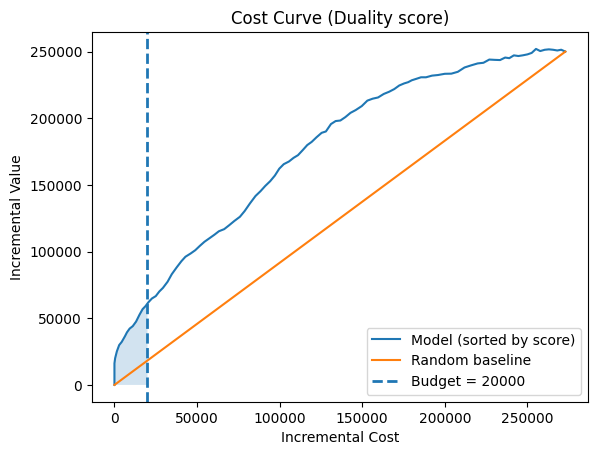

In [68]:
score_test = tau_r_test - lambda_star * tau_c_test

x, y, max_cost, max_value = make_cost_curve(
    score=score_test,
    T=T_test,
    Y_value=Yg_test,
    Y_cost=Yc_test,
    e=e_test,
    w=W_test,
    n_points=101
)

inc_value_all = np.sum(W_test * (T_test * Yg_test / e_test - (1 - T_test) * Yg_test / (1 - e_test)))
inc_cost_all  = np.sum(W_test * (T_test * Yc_test / e_test - (1 - T_test) * Yc_test / (1 - e_test)))

# 전체 AUCC
aucc_all, auc_model_all, auc_random_all, slope = aucc_from_cost_curve(
    x, y, inc_cost_all=inc_cost_all, inc_value_all=inc_value_all, budget=None
)

# budget AUCC
aucc_B, auc_model_B, auc_random_B, slope = aucc_from_cost_curve(
    x, y, inc_cost_all=inc_cost_all, inc_value_all=inc_value_all, budget=BUDGET
)

print(f"[전체] AUCC={aucc_all:.4f} (auc_model={auc_model_all:.2e}, auc_random={auc_random_all:.2e})")
print(f"[budget={BUDGET}] AUCC={aucc_B:.4f} (auc_model={auc_model_B:.2e}, auc_random={auc_random_B:.2e})")

plot_cost_curve(x, y, max_cost, max_value, title="Cost Curve (Duality score)", budget=BUDGET)